In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Telco-Customer-Churn.csv")
data.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00000,Male,0,No,Yes,61,Yes,Yes,DSL,No,...,Yes,No internet service,Yes,No internet service,One year,Yes,Electronic check,57.06,3480.66,No
1,CUST00001,Female,0,No,No,68,No,Yes,No,No internet service,...,No internet service,No internet service,No,No internet service,Month-to-month,No,Mailed check,111.08,7553.44,Yes
2,CUST00002,Male,0,No,No,62,No,No,No,No,...,No internet service,No internet service,No,No,Month-to-month,No,Mailed check,71.77,4449.74,No
3,CUST00003,Male,1,Yes,No,1,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No,Month-to-month,No,Bank transfer (automatic),20.10,20.10,Yes
4,CUST00004,Male,0,Yes,Yes,53,No,No,DSL,Yes,...,No internet service,No internet service,No,Yes,Month-to-month,No,Electronic check,89.88,4763.64,Yes
5,CUST00005,Female,0,Yes,No,15,Yes,Yes,Fiber optic,No internet service,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,71.35,1070.25,Yes
6,CUST00006,Male,1,Yes,No,54,No,No phone service,DSL,No,...,Yes,No internet service,No internet service,No internet service,One year,Yes,Electronic check,51.71,2792.34,No
7,CUST00007,Male,0,No,Yes,42,Yes,Yes,DSL,No internet service,...,Yes,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),22.04,925.68,No
8,CUST00008,Male,1,No,Yes,60,No,No,Fiber optic,No internet service,...,Yes,No internet service,No internet service,Yes,Month-to-month,No,Credit card (automatic),39.87,2392.20,No
9,CUST00009,Female,1,No,Yes,37,No,No,DSL,No,...,No internet service,No internet service,No internet service,Yes,One year,Yes,Mailed check,36.16,1337.92,No


EDA

In [5]:
print(data.shape)
print(data.info())

(5000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5000 non-null   object 
 1   gender            5000 non-null   object 
 2   SeniorCitizen     5000 non-null   int64  
 3   Partner           5000 non-null   object 
 4   Dependents        5000 non-null   object 
 5   tenure            5000 non-null   int64  
 6   PhoneService      5000 non-null   object 
 7   MultipleLines     5000 non-null   object 
 8   InternetService   5000 non-null   object 
 9   OnlineSecurity    5000 non-null   object 
 10  OnlineBackup      5000 non-null   object 
 11  DeviceProtection  5000 non-null   object 
 12  TechSupport       5000 non-null   object 
 13  StreamingTV       5000 non-null   object 
 14  StreamingMovies   5000 non-null   object 
 15  Contract          5000 non-null   object 
 16  PaperlessBilling  5000 non-null

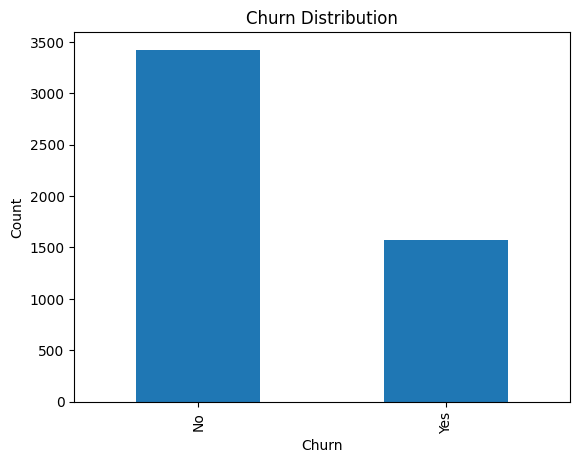

In [6]:
data['Churn'].value_counts().plot(kind='bar')  #chrun - value count
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

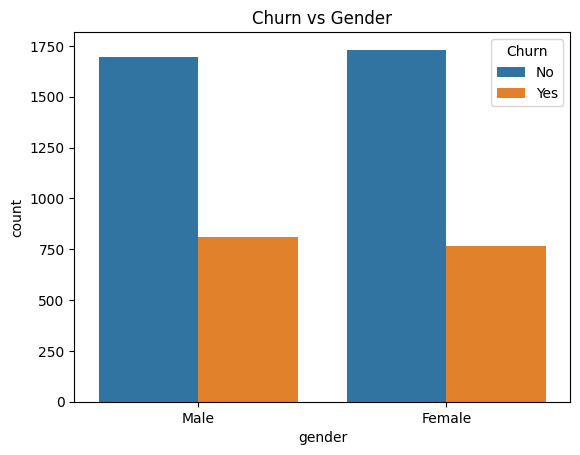

In [7]:
sns.countplot(x='gender', hue='Churn', data=data)
plt.title("Churn vs Gender")
plt.show()

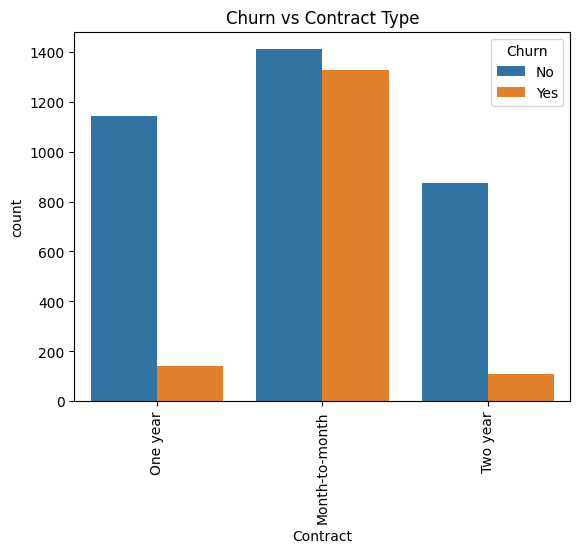

In [8]:
sns.countplot(x='Contract', hue='Churn', data=data)
plt.title("Churn vs Contract Type")
plt.xticks(rotation=90)
plt.show()

In [9]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00000,Male,0,No,Yes,61,Yes,Yes,DSL,No,...,Yes,No internet service,Yes,No internet service,One year,Yes,Electronic check,57.06,3480.66,No
1,CUST00001,Female,0,No,No,68,No,Yes,No,No internet service,...,No internet service,No internet service,No,No internet service,Month-to-month,No,Mailed check,111.08,7553.44,Yes
2,CUST00002,Male,0,No,No,62,No,No,No,No,...,No internet service,No internet service,No,No,Month-to-month,No,Mailed check,71.77,4449.74,No
3,CUST00003,Male,1,Yes,No,1,No,No phone service,No,No internet service,...,No internet service,No internet service,No internet service,No,Month-to-month,No,Bank transfer (automatic),20.10,20.10,Yes
4,CUST00004,Male,0,Yes,Yes,53,No,No,DSL,Yes,...,No internet service,No internet service,No,Yes,Month-to-month,No,Electronic check,89.88,4763.64,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUST04995,Male,0,Yes,No,21,Yes,No phone service,No,No,...,No,No internet service,Yes,No internet service,Two year,Yes,Bank transfer (automatic),85.18,1788.78,No
4996,CUST04996,Female,0,Yes,No,44,Yes,No,DSL,Yes,...,No internet service,No internet service,Yes,Yes,Month-to-month,No,Bank transfer (automatic),25.97,1142.68,No
4997,CUST04997,Male,1,Yes,Yes,60,No,Yes,DSL,No internet service,...,Yes,No,No,No internet service,Month-to-month,No,Credit card (automatic),97.29,5837.40,No
4998,CUST04998,Female,0,No,No,20,No,Yes,Fiber optic,Yes,...,Yes,No,No,No,One year,No,Credit card (automatic),80.62,1612.40,No


DROP IRRELEVANT COLUMN

In [10]:
data.drop("customerID", axis=1, inplace = True)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,61,Yes,Yes,DSL,No,No,Yes,No internet service,Yes,No internet service,One year,Yes,Electronic check,57.06,3480.66,No
1,Female,0,No,No,68,No,Yes,No,No internet service,No,No internet service,No internet service,No,No internet service,Month-to-month,No,Mailed check,111.08,7553.44,Yes
2,Male,0,No,No,62,No,No,No,No,No internet service,No internet service,No internet service,No,No,Month-to-month,No,Mailed check,71.77,4449.74,No
3,Male,1,Yes,No,1,No,No phone service,No,No internet service,Yes,No internet service,No internet service,No internet service,No,Month-to-month,No,Bank transfer (automatic),20.10,20.10,Yes
4,Male,0,Yes,Yes,53,No,No,DSL,Yes,No internet service,No internet service,No internet service,No,Yes,Month-to-month,No,Electronic check,89.88,4763.64,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Male,0,Yes,No,21,Yes,No phone service,No,No,Yes,No,No internet service,Yes,No internet service,Two year,Yes,Bank transfer (automatic),85.18,1788.78,No
4996,Female,0,Yes,No,44,Yes,No,DSL,Yes,Yes,No internet service,No internet service,Yes,Yes,Month-to-month,No,Bank transfer (automatic),25.97,1142.68,No
4997,Male,1,Yes,Yes,60,No,Yes,DSL,No internet service,Yes,Yes,No,No,No internet service,Month-to-month,No,Credit card (automatic),97.29,5837.40,No
4998,Female,0,No,No,20,No,Yes,Fiber optic,Yes,Yes,Yes,No,No,No,One year,No,Credit card (automatic),80.62,1612.40,No


yes - 1
No - 0

In [11]:
data['Churn'].value_counts()

,count
Churn,
No,3425
Yes,1575


In [12]:
data["Churn"] = data["Churn"].astype(str)

In [13]:
data["Churn"] = data["Churn"].str.strip().str.lower()
data["Churn"] = data["Churn"].map({"yes": 1, "no": 0})

In [14]:
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,61,Yes,Yes,DSL,No,No,Yes,No internet service,Yes,No internet service,One year,Yes,Electronic check,57.06,3480.66,0
1,Female,0,No,No,68,No,Yes,No,No internet service,No,No internet service,No internet service,No,No internet service,Month-to-month,No,Mailed check,111.08,7553.44,1
2,Male,0,No,No,62,No,No,No,No,No internet service,No internet service,No internet service,No,No,Month-to-month,No,Mailed check,71.77,4449.74,0
3,Male,1,Yes,No,1,No,No phone service,No,No internet service,Yes,No internet service,No internet service,No internet service,No,Month-to-month,No,Bank transfer (automatic),20.10,20.10,1
4,Male,0,Yes,Yes,53,No,No,DSL,Yes,No internet service,No internet service,No internet service,No,Yes,Month-to-month,No,Electronic check,89.88,4763.64,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,Male,0,Yes,No,21,Yes,No phone service,No,No,Yes,No,No internet service,Yes,No internet service,Two year,Yes,Bank transfer (automatic),85.18,1788.78,0
4996,Female,0,Yes,No,44,Yes,No,DSL,Yes,Yes,No internet service,No internet service,Yes,Yes,Month-to-month,No,Bank transfer (automatic),25.97,1142.68,0
4997,Male,1,Yes,Yes,60,No,Yes,DSL,No internet service,Yes,Yes,No,No,No internet service,Month-to-month,No,Credit card (automatic),97.29,5837.40,0
4998,Female,0,No,No,20,No,Yes,Fiber optic,Yes,Yes,Yes,No,No,No,One year,No,Credit card (automatic),80.62,1612.40,0


In [15]:
# data.value_counts('Churn')

data['Churn'].value_counts()

,count
Churn,
0,3425
1,1575


Encode all categorical data

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = data.select_dtypes(include="object").columns

for col in categorical_cols:
    data[col] = le.fit_transform(data[col])

AS USUAL, TRAIN TEST SPLIT FOR PREDICTION

In [17]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

**Standard scalar**

It is a preprocessing technique used to standardize numerical data.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Stratify is used when data is imbalanced

Target is categorical (0/1, Yes/No)

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

StandardScaler()


In [20]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_model.fit(X_train, y_train)


SVC(random_state=42)

In [21]:
y_pred_svm = svm_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

print("\nConfusion Matrix:\n",
      confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.702

Confusion Matrix:
 [[605  80]
 [218  97]]


In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

data = np.array([[10], [20], [30]])

ss = StandardScaler()
standard_scaled = ss.fit_transform(data)

print("StandardScaler Output:")
print(standard_scaled)

mm = MinMaxScaler()
minmax_scaled = mm.fit_transform(data)

print("\nMinMaxScaler Output:")
print(minmax_scaled)


StandardScaler Output:
[[-1.22474487]
 [ 0.        ]
 [ 1.22474487]]

MinMaxScaler Output:
[[0. ]
 [0.5]
 [1. ]]
